# Analyse exploratoire avant l'ACM — KaraFun

**Objectif :** comprendre les variables *avant* de décider comment les regrouper pour l'ACM.

On se pose trois questions :
1. **Chaque variable, seule** : combien de modalités ? Lesquelles sont trop rares ?
2. **Les variables deux à deux** : lesquelles sont liées entre elles (V de Cramér) ?
3. **Les doublons** : y a-t-il des variables qui disent exactement la même chose ?

Les réponses serviront à décider :
- quelles modalités regrouper,
- quelles variables mettre en **actives** (elles construisent les axes de l'ACM)
  ou en **illustratives** (projetées après coup, pour interpréter),
- quelles variables retirer.

> On lit le fichier `td_clustering_karafun.csv` **sans jamais le modifier** :
> pandas le charge en mémoire dans un tableau `df`, et on ne fait aucun `to_csv`.
> Pas besoin de cloner le CSV.

## 0. Imports et réglages

In [1]:
import pandas as pd                     # manipuler des tableaux de données
import numpy as np                      # calculs numériques (racine carrée, etc.)
import matplotlib.pyplot as plt         # graphiques
from matplotlib.colors import LinearSegmentedColormap   # créer un dégradé de couleurs
from scipy.stats import chi2_contingency                # test du khi-deux

# Afficher toutes les colonnes et toutes les lignes des tableaux pandas
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 200)

# Couleurs des graphiques
BLEU = "#2a78d6"          # couleur des barres
GRIS = "#898781"          # couleur des textes secondaires / lignes de repère
# Dégradé pour la heatmap : blanc = pas de lien, bleu foncé = lien très fort
DEGRADE_BLEU = LinearSegmentedColormap.from_list(
    "bleus", ["#fcfcfb", "#cde2fb", "#6da7ec", "#256abf", "#0d366b"]
)

# Style général : on enlève les bordures du haut et de droite, grille discrète
plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": GRIS,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#e1e0d9",
    "axes.axisbelow": True,        # la grille passe derrière les barres
})

## 1. Chargement des données

In [2]:
df = pd.read_csv("td_clustering_karafun.csv")

print("Nombre de lignes (clients)  :", df.shape[0])
print("Nombre de colonnes (variables) :", df.shape[1])
df.head()

Nombre de lignes (clients)  : 341092
Nombre de colonnes (variables) : 16


,id_anonyme,anciennete_client_tr,anciennete_abonnement_tr,statut_abonnement,type_client,type_very_first_abo,type_first_abo_last_streak,ratio_fidelite_tr,methode_paiement,nb_abo_periode,valeur_12M_tr,avg_sessions_actifs_tr,avg_songs_sessions_tr,utilise_remote,zone_geo,contactable
0,fbb58c58395ab62899c58d6a52f8159ca12ddd7f46bfe2...,00_moins_1_mois,00_moins_1_mois,actif,nouveau,payant,payant,99_vient_de_s_abonner,Apple,1,00_moins_10,02_1a2,01_1a2,non,US,oui
1,8c981dbb88db4abcfd1c07b30ec42c370195fabaf74b8a...,00_moins_1_mois,00_moins_1_mois,actif,nouveau,payant,payant,99_vient_de_s_abonner,Android,1,00_moins_10,03_2a3,02_2a3,non,Europe,oui
2,a4b6c3d31fb413aa830dbb423bd3d8446438dae71d9973...,00_moins_1_mois,00_moins_1_mois,actif,nouveau,payant,payant,99_vient_de_s_abonner,Paypal,1,00_moins_10,03_2a3,09_15a20,non,Europe,non
3,ef9a45455295911d59cd8a9c76d32d582709e40a5a238f...,00_moins_1_mois,00_moins_1_mois,actif,nouveau,payant,payant,99_vient_de_s_abonner,Paypal,1,00_moins_10,02_1a2,09_15a20,non,CA,oui
4,91d37bd372c738eddb00a6b2878877161fb26a2a519bf8...,00_moins_1_mois,00_moins_1_mois,actif,nouveau,payant,payant,99_vient_de_s_abonner,Paypal,1,00_moins_10,00_pas_de_session,00_pas_de_session,non,FR,oui


## 2. Contrôle qualité

Avant toute analyse, on vérifie :
- le **type** de chaque variable (texte = qualitative, nombre = quantitative),
- les **valeurs manquantes** (l'ACM ne les accepte pas telles quelles),
- le **nombre de modalités** de chaque variable,
- les **doublons** sur l'identifiant client.

In [3]:
controle = pd.DataFrame({
    "type": df.dtypes,                  # type de la colonne
    "nb_manquants": df.isna().sum(),    # nombre de cases vides
    "nb_modalites": df.nunique(),       # nombre de valeurs différentes
})
controle

,type,nb_manquants,nb_modalites
id_anonyme,str,0,341092
anciennete_client_tr,str,0,20
anciennete_abonnement_tr,str,0,20
statut_abonnement,str,0,2
type_client,str,0,4
type_very_first_abo,str,0,3
type_first_abo_last_streak,str,0,3
ratio_fidelite_tr,str,0,6
methode_paiement,str,0,7
nb_abo_periode,int64,0,12


In [4]:
# duplicated() renvoie True pour chaque identifiant déjà vu plus haut
nb_doublons = df["id_anonyme"].duplicated().sum()
print("Nombre d'identifiants en double :", nb_doublons)

Nombre d'identifiants en double : 0


**À retenir :**
- Aucune valeur manquante, aucun doublon : les données sont propres.
- `id_anonyme` a autant de modalités que de lignes : c'est un identifiant, **il ne rentrera pas dans l'ACM**.
- `nb_abo_periode` est la **seule variable numérique**. Toutes les autres sont déjà qualitatives.
- Certaines variables ont beaucoup de modalités (20 pour les anciennetés) : elles pèseront beaucoup dans l'ACM.

## 3. La variable quantitative : `nb_abo_periode`

L'ACM n'accepte que des variables qualitatives. Il faudra donc découper `nb_abo_periode` en classes.
Pour choisir les classes, on regarde d'abord sa distribution.

In [5]:
# Résumé statistique : moyenne, écart-type, min, quartiles, max
df["nb_abo_periode"].describe()

count    341092.000000
mean          5.454860
std           4.356785
min           1.000000
25%           1.000000
50%           4.000000
75%          10.000000
max          12.000000
Name: nb_abo_periode, dtype: float64

In [6]:
# Effectif et pourcentage pour chaque valeur de 1 à 12
effectifs = df["nb_abo_periode"].value_counts().sort_index()
pourcentages = (effectifs / len(df) * 100).round(1)
pd.DataFrame({"effectif": effectifs, "pourcentage (%)": pourcentages})

,effectif,pourcentage (%)
nb_abo_periode,,
1,97048,28.5
2,40958,12.0
3,25415,7.5
4,18889,5.5
5,15444,4.5
6,14788,4.3
7,15579,4.6
8,10528,3.1
9,9397,2.8


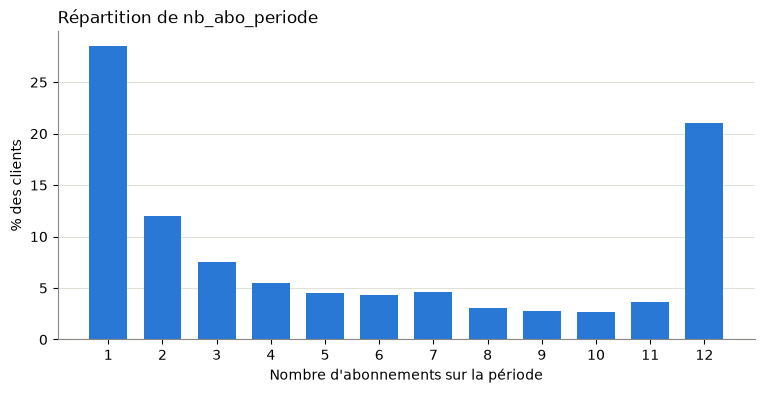

In [7]:
# Diagramme en barres (une barre par valeur, car la variable ne prend que 12 valeurs)
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(pourcentages.index, pourcentages.values, color=BLEU, width=0.7)
ax.set_xticks(pourcentages.index)
ax.set_xlabel("Nombre d'abonnements sur la période")
ax.set_ylabel("% des clients")
ax.set_title("Répartition de nb_abo_periode", loc="left")
plt.show()

**À retenir :** la distribution a une **forme en U**. Beaucoup de clients ont 1 abonnement (28,5 %)
ou 12 (21 %), peu entre les deux. Les valeurs 1 et 12 méritent donc chacune leur propre classe,
et les valeurs du milieu doivent être regroupées.

## 4. Les variables qualitatives, une par une

**Pourquoi c'est important pour l'ACM :** une modalité **rare** (moins de ~5 % des individus)
pèse très lourd dans le calcul des axes. Elle peut créer à elle seule un axe sans intérêt.
On repère donc toutes les modalités sous 5 %.

In [8]:
# Liste des variables qualitatives : toutes sauf l'identifiant et la variable numérique
variables_quali = [col for col in df.columns if col not in ("id_anonyme", "nb_abo_periode")]
print(variables_quali)

['anciennete_client_tr', 'anciennete_abonnement_tr', 'statut_abonnement', 'type_client', 'type_very_first_abo', 'type_first_abo_last_streak', 'ratio_fidelite_tr', 'methode_paiement', 'valeur_12M_tr', 'avg_sessions_actifs_tr', 'avg_songs_sessions_tr', 'utilise_remote', 'zone_geo', 'contactable']


In [9]:
# Petite fonction qui renvoie le tableau effectifs + pourcentages d'une variable.
# On l'écrit une fois, puis on la réutilise pour chaque variable.
def repartition(col):
    effectifs = df[col].value_counts().sort_index()
    pourcentages = (effectifs / len(df) * 100).round(1)
    return pd.DataFrame({"effectif": effectifs, "pourcentage (%)": pourcentages})

for col in variables_quali:
    print(f"--- {col} ---")
    print(repartition(col))
    print()

--- anciennete_client_tr ---
                      effectif  pourcentage (%)
anciennete_client_tr                           
00_moins_1_mois          12474              3.7
01_1_mois                12680              3.7
02_2_mois                10455              3.1
03_3_mois                10085              3.0
04_4_mois                 9835              2.9
05_5_mois                12310              3.6
06_6_mois                32676              9.6
07_7a9_mois              35479             10.4
08_10a12_mois            30305              8.9
09_13a15_mois            16764              4.9
10_16a18_mois            21789              6.4
11_19a21_mois            13268              3.9
12_22a24_mois            11110              3.3
13_25a30_mois            24140              7.1
14_31a36_mois            17481              5.1
15_37a48_mois            21919              6.4
16_49a60_mois            12168              3.6
17_61a84_mois            15077              4.4
18_85a120_m

### Tableau de synthèse : les modalités rares

Plutôt que de relire tous les tableaux, on résume, pour chaque variable :
son nombre de modalités, sa modalité la plus rare, et combien de ses modalités sont sous 5 %.

In [10]:
SEUIL = 5   # en %, en dessous on considère la modalité comme rare

lignes = []
for col in variables_quali + ["nb_abo_periode"]:
    pct = df[col].value_counts(normalize=True) * 100     # pourcentages de chaque modalité
    lignes.append({
        "variable": col,
        "nb_modalites": len(pct),
        "modalite_la_plus_rare": pct.idxmin(),           # nom de la plus petite modalité
        "pct_min (%)": round(pct.min(), 2),               # son pourcentage
        f"nb_modalites_sous_{SEUIL}%": (pct < SEUIL).sum(),
        "modalites_sous_seuil": ", ".join(str(m) for m in pct[pct < SEUIL].index),
    })

synthese = pd.DataFrame(lignes).sort_values("pct_min (%)")
synthese

,variable,nb_modalites,modalite_la_plus_rare,pct_min (%),nb_modalites_sous_5%,modalites_sous_seuil
7,methode_paiement,7,Others,0.00,3,"Amazon, Credit, Others"
12,zone_geo,11,Autre/Inconnu,0.01,6,"Oceanie, Asie, Amerique_Nord_Autre, Amerique_S..."
1,anciennete_abonnement_tr,20,19_121_mois_et_plus,0.04,12,"04_4_mois, 09_13a15_mois, 10_16a18_mois, 13_25..."
9,avg_sessions_actifs_tr,14,13_50_et_plus,0.18,8,"07_6a8, 06_5a6, 09_10a15, 08_8a10, 10_15a20, 1..."
5,type_first_abo_last_streak,3,offert,0.19,2,"reduc, offert"
4,type_very_first_abo,3,reduc,0.60,2,"offert, reduc"
10,avg_songs_sessions_tr,13,12_50_et_plus,0.97,2,"11_30a50, 12_50_et_plus"
0,anciennete_client_tr,20,19_121_mois_et_plus,2.09,13,"09_13a15_mois, 17_61a84_mois, 18_85a120_mois, ..."
8,valeur_12M_tr,12,10_90a110,2.45,4,"04_25a30, 07_50a60, 03_20a25, 10_90a110"
14,nb_abo_periode,12,10,2.67,7,"7, 5, 6, 11, 8, 9, 10"


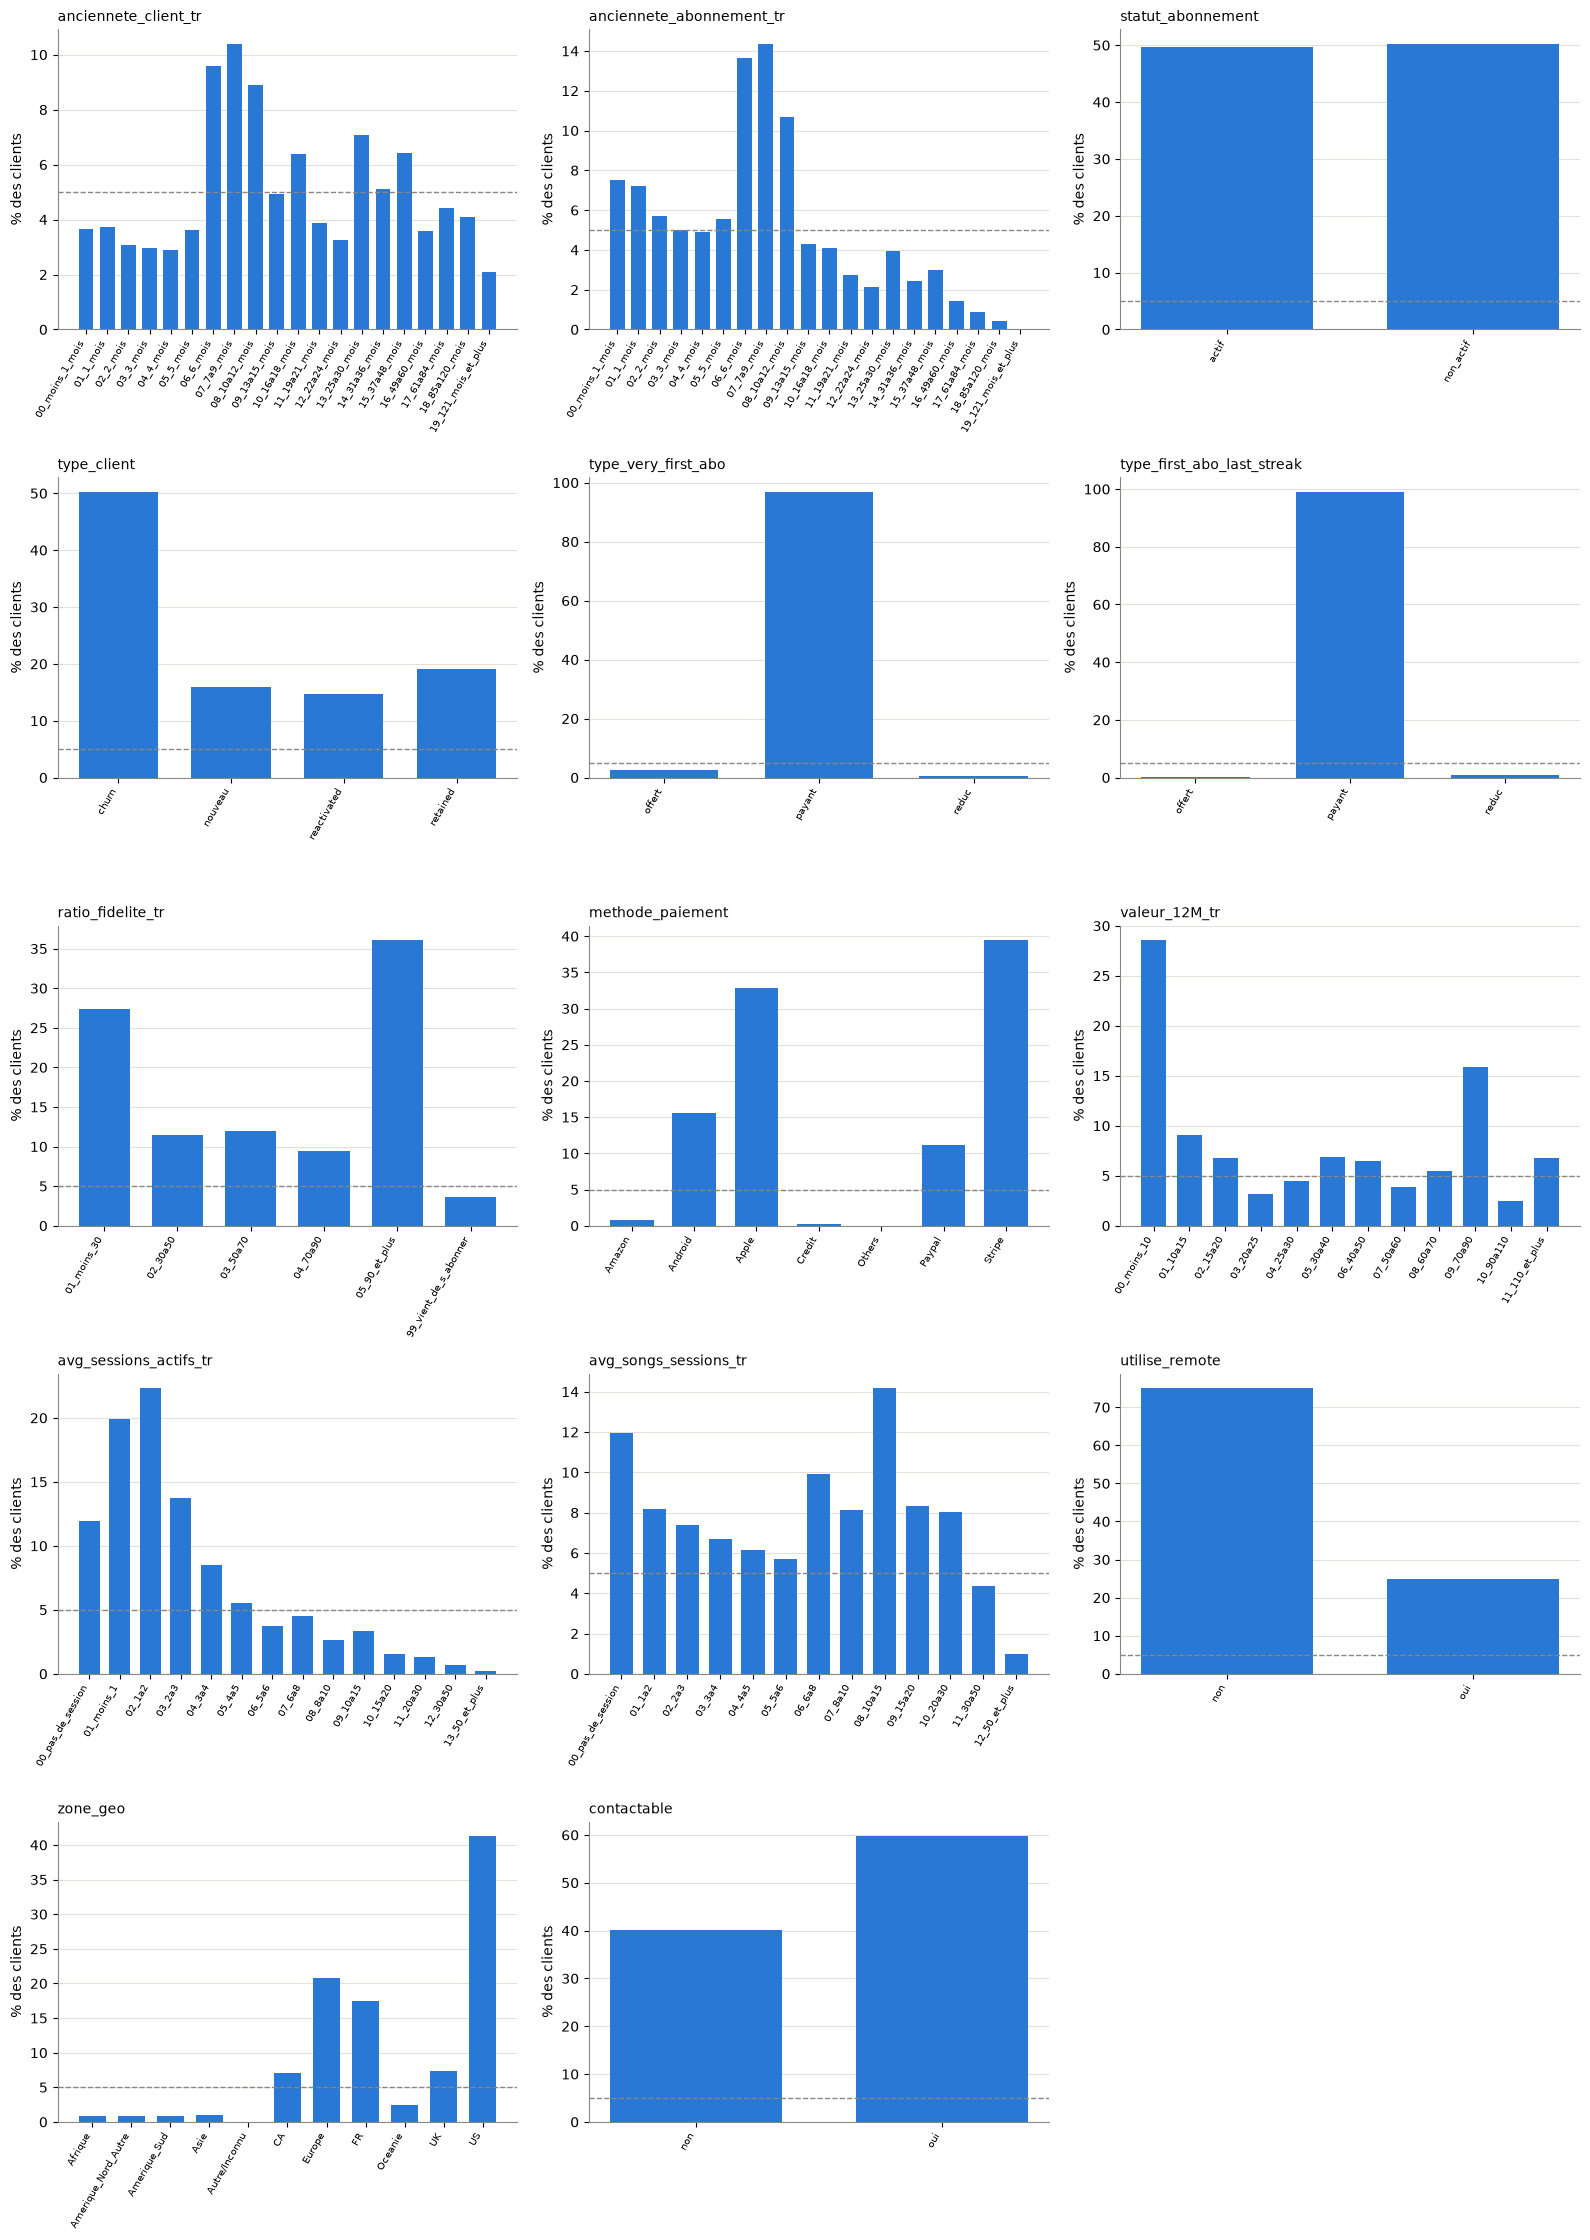

In [11]:
# Un graphique par variable, avec une ligne pointillée au seuil de 5 %.
# Les barres sous la ligne sont les modalités à regrouper.
nb_colonnes = 3
nb_lignes = (len(variables_quali) + nb_colonnes - 1) // nb_colonnes    # arrondi au-dessus

fig, axes = plt.subplots(nb_lignes, nb_colonnes, figsize=(16, 4.5 * nb_lignes))
axes = axes.flatten()        # on passe d'une grille à une simple liste de cases

for ax, col in zip(axes, variables_quali):
    pct = df[col].value_counts(normalize=True).sort_index() * 100
    ax.bar(range(len(pct)), pct.values, color=BLEU, width=0.7)
    ax.axhline(SEUIL, color=GRIS, linestyle="--", linewidth=1)     # ligne du seuil
    ax.set_xticks(range(len(pct)))
    ax.set_xticklabels(pct.index, rotation=60, ha="right", fontsize=7)
    ax.set_ylabel("% des clients")
    ax.set_title(col, loc="left", fontsize=10)

for ax in axes[len(variables_quali):]:     # on cache les cases vides
    ax.set_visible(False)

plt.tight_layout()
plt.show()

**À retenir :**
- `type_first_abo_last_streak` : 99,1 % de « payant ». La variable est **quasi constante**,
  elle n'apporte presque aucune information. On l'**exclut** ou on la met en illustrative.
- `methode_paiement` : `Others` n'a qu'**1 client**, `Credit` 0,2 %, `Amazon` 0,8 %. À regrouper.
- `zone_geo` : `Autre/Inconnu` (22 clients), et plusieurs zones autour de 1 %. À regrouper.
- `type_very_first_abo` : `offert` et `reduc` sont très rares.
- Anciennetés, sessions, chansons, valeur : beaucoup de modalités, et des queues de distribution sous 5 %.

## 5. Les liens entre variables : khi-deux et V de Cramér

### Le principe
Pour deux variables qualitatives, on construit leur **tableau croisé** (effectifs de chaque couple de modalités).

- Le **test du khi-deux** compare ce tableau à celui qu'on aurait si les deux variables étaient
  **indépendantes**. Plus l'écart est grand, plus la statistique χ² est grande.
- **Problème :** avec 341 092 clients, le moindre petit lien donne une p-value ≈ 0.
  La p-value dit « il y a un lien », mais pas **s'il est fort**.
- Le **V de Cramér** corrige cela : il ramène le χ² entre **0** (aucun lien) et **1** (lien parfait) :

$$V = \sqrt{\frac{\chi^2}{n \times (\min(\text{nb lignes}, \text{nb colonnes}) - 1)}}$$

### Grille de lecture (indicative)
| V | lien |
|---|---|
| < 0,1 | très faible |
| 0,1 à 0,3 | modéré |
| 0,3 à 0,5 | fort |
| > 0,5 | très fort |
| = 1 | les deux variables disent la même chose (doublon) |

### Ce qu'on cherche pour l'ACM
L'ACM résume les liens entre variables. Il faut donc **des liens**, mais **pas de doublons** :
deux variables identiques créeraient un axe qui ne fait que répéter la même information.

In [12]:
def v_de_cramer(var1, var2):
    """Calcule le V de Cramér entre deux variables qualitatives de df."""
    tableau = pd.crosstab(df[var1], df[var2])    # tableau croisé des effectifs
    chi2 = chi2_contingency(tableau)[0]           # [0] = la statistique du khi-deux
    n = tableau.values.sum()                      # nombre total d'individus
    k = min(tableau.shape) - 1                    # (plus petit nombre de modalités) - 1
    return np.sqrt(chi2 / (n * k))

In [13]:
# Exemple sur un couple : le tableau croisé, le test du khi-deux, puis le V de Cramér
tableau = pd.crosstab(df["type_client"], df["utilise_remote"])
print(tableau, "\n")

chi2, p_value, ddl, _ = chi2_contingency(tableau)
print(f"khi-deux = {chi2:.1f}   degrés de liberté = {ddl}   p-value = {p_value:.2e}")
print(f"V de Cramér = {v_de_cramer('type_client', 'utilise_remote'):.3f}")

utilise_remote     non    oui
type_client                  
churn           131888  39598
nouveau          38907  15714
reactivated      33522  16343
retained         51747  13373 

khi-deux = 3051.6   degrés de liberté = 3   p-value = 0.00e+00
V de Cramér = 0.095


La p-value est quasi nulle (lien « significatif »), alors que le V de Cramér montre un lien
**faible**. C'est exactement pourquoi on se fie au V de Cramér plutôt qu'à la p-value.

### Matrice des V de Cramér : toutes les variables deux à deux

On garde `nb_abo_periode` telle quelle : chacune de ses 12 valeurs est traitée comme une modalité.
Le calcul prend quelques secondes (13 × 13 couples sur 341 092 lignes).

In [14]:
variables = variables_quali + ["nb_abo_periode"]

# Tableau carré vide, qu'on remplit case par case
matrice_v = pd.DataFrame(index=variables, columns=variables, dtype=float)

for var1 in variables:
    for var2 in variables:
        if var1 == var2:
            matrice_v.loc[var1, var2] = 1.0     # une variable est parfaitement liée à elle-même
        else:
            matrice_v.loc[var1, var2] = v_de_cramer(var1, var2)

matrice_v.round(2)

,anciennete_client_tr,anciennete_abonnement_tr,statut_abonnement,type_client,type_very_first_abo,type_first_abo_last_streak,ratio_fidelite_tr,methode_paiement,valeur_12M_tr,avg_sessions_actifs_tr,avg_songs_sessions_tr,utilise_remote,zone_geo,contactable,nb_abo_periode
anciennete_client_tr,1.00,0.55,0.32,0.44,0.13,0.05,0.50,0.06,0.22,0.07,0.05,0.07,0.04,0.35,0.26
anciennete_abonnement_tr,0.55,1.00,0.48,0.54,0.07,0.08,0.40,0.08,0.25,0.10,0.07,0.14,0.05,0.18,0.29
statut_abonnement,0.32,0.48,1.00,1.00,0.07,0.01,0.69,0.08,0.62,0.27,0.17,0.04,0.12,0.03,0.64
type_client,0.44,0.54,1.00,1.00,0.16,0.02,0.51,0.08,0.53,0.18,0.12,0.09,0.08,0.17,0.59
type_very_first_abo,0.13,0.07,0.07,0.16,1.00,0.35,0.09,0.07,0.04,0.03,0.05,0.05,0.04,0.05,0.07
type_first_abo_last_streak,0.05,0.08,0.01,0.02,0.35,1.00,0.02,0.64,0.02,0.02,0.02,0.03,0.02,0.04,0.04
ratio_fidelite_tr,0.50,0.40,0.69,0.51,0.09,0.02,1.00,0.04,0.39,0.16,0.06,0.02,0.07,0.12,0.41
methode_paiement,0.06,0.08,0.08,0.08,0.07,0.64,0.04,1.00,0.16,0.03,0.07,0.07,0.11,0.20,0.05
valeur_12M_tr,0.22,0.25,0.62,0.53,0.04,0.02,0.39,0.16,1.00,0.13,0.05,0.06,0.12,0.12,0.63
avg_sessions_actifs_tr,0.07,0.10,0.27,0.18,0.03,0.02,0.16,0.03,0.13,1.00,0.30,0.21,0.04,0.09,0.13


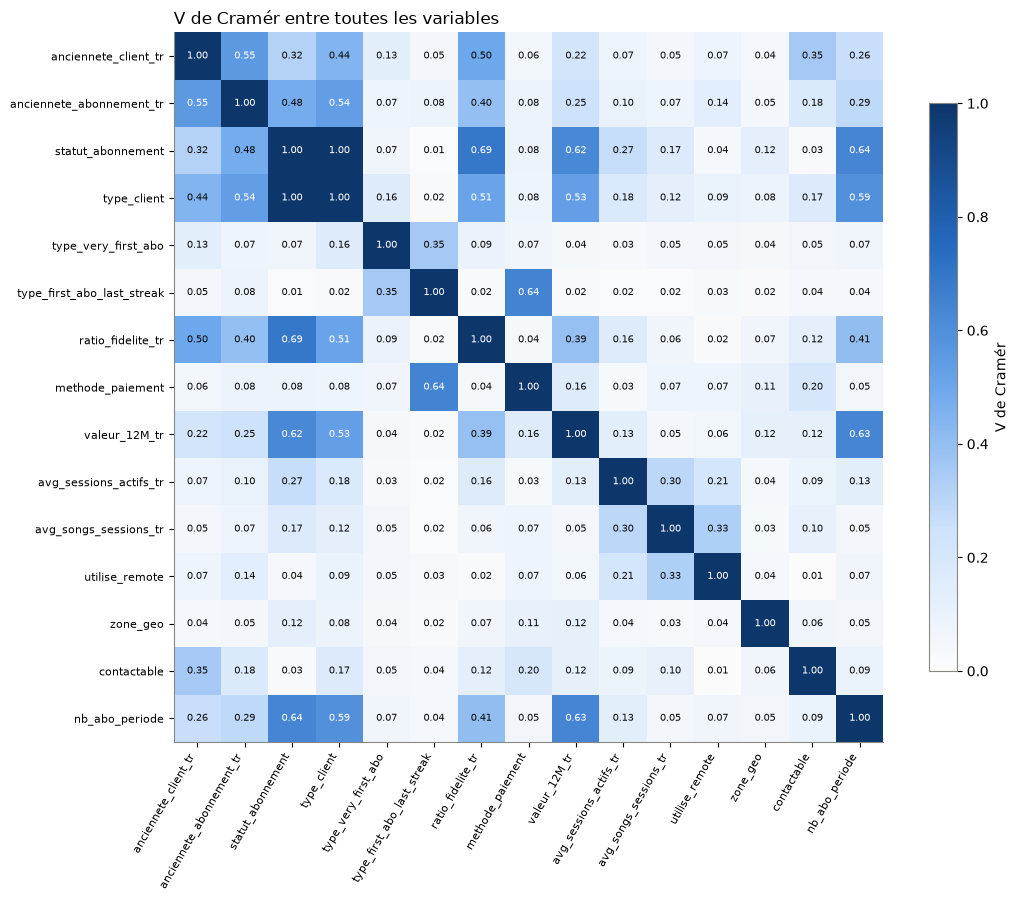

In [15]:
# Heatmap : plus la case est foncée, plus le lien est fort
fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(matrice_v.values, cmap=DEGRADE_BLEU, vmin=0, vmax=1)

ax.set_xticks(range(len(variables)))
ax.set_yticks(range(len(variables)))
ax.set_xticklabels(variables, rotation=60, ha="right", fontsize=8)
ax.set_yticklabels(variables, fontsize=8)
ax.grid(False)

# On écrit la valeur dans chaque case (texte blanc sur les cases foncées)
for i in range(len(variables)):
    for j in range(len(variables)):
        valeur = matrice_v.iloc[i, j]
        couleur_texte = "white" if valeur > 0.5 else "#0b0b0b"
        ax.text(j, i, f"{valeur:.2f}", ha="center", va="center", fontsize=7, color=couleur_texte)

fig.colorbar(image, ax=ax, label="V de Cramér", shrink=0.8)
ax.set_title("V de Cramér entre toutes les variables", loc="left")
plt.tight_layout()
plt.show()

In [16]:
# Classement des couples du plus lié au moins lié.
# On ne garde que les cases au-dessus de la diagonale (sinon chaque couple apparaît deux fois).
couples = []
for i in range(len(variables)):
    for j in range(i + 1, len(variables)):
        couples.append({
            "variable_1": variables[i],
            "variable_2": variables[j],
            "V_de_Cramer": round(matrice_v.iloc[i, j], 3),
        })

classement = pd.DataFrame(couples).sort_values("V_de_Cramer", ascending=False)
classement.head(20)

,variable_1,variable_2,V_de_Cramer
27,statut_abonnement,type_client,1.000
30,statut_abonnement,ratio_fidelite_tr,0.693
61,type_first_abo_last_streak,methode_paiement,0.644
38,statut_abonnement,nb_abo_periode,0.635
89,valeur_12M_tr,nb_abo_periode,0.633
32,statut_abonnement,valeur_12M_tr,0.621
49,type_client,nb_abo_periode,0.592
0,anciennete_client_tr,anciennete_abonnement_tr,0.555
15,anciennete_abonnement_tr,type_client,0.537
43,type_client,valeur_12M_tr,0.532


## 6. Zoom sur les couples qui posent question

La matrice signale des liens forts. On regarde les tableaux croisés pour comprendre **d'où ils viennent**.
`normalize="index"` donne des **pourcentages en ligne** : chaque ligne fait 100 %.

### 6.1 `statut_abonnement` × `type_client` (V = 1)

In [17]:
(pd.crosstab(df["type_client"], df["statut_abonnement"], normalize="index") * 100).round(1)

statut_abonnement,actif,non_actif
type_client,,
churn,0.0,100.0
nouveau,100.0,0.0
reactivated,100.0,0.0
retained,100.0,0.0


Les clients `churn` sont **tous** `non_actif`, et tous les autres sont `actif`.
`statut_abonnement` est donc entièrement déduite de `type_client` : c'est un **doublon**.
→ On garde `type_client` (plus détaillée) et on **retire** `statut_abonnement`.

### 6.2 `type_very_first_abo` × `type_first_abo_last_streak`

In [18]:
pd.crosstab(df["type_very_first_abo"], df["type_first_abo_last_streak"])

type_first_abo_last_streak,offert,payant,reduc
type_very_first_abo,,,
offert,119,8239,108
payant,537,328794,1252
reduc,6,908,1129


Presque tout le monde est `payant` / `payant`. Le lien vient uniquement des quelques centaines
de clients `offert` ou `reduc`.

### 6.3 `methode_paiement` × `type_first_abo_last_streak` : un lien fort qui vient d'une modalité rare

In [19]:
pd.crosstab(df["methode_paiement"], df["type_first_abo_last_streak"])

type_first_abo_last_streak,offert,payant,reduc
methode_paiement,,,
Amazon,0,2846,0
Android,3,52883,1
Apple,2,111734,191
Credit,573,29,0
Others,0,1,0
Paypal,26,37426,651
Stripe,58,133022,1646


Le V de Cramér est élevé, mais il vient presque entièrement des ~600 clients `Credit`,
dont 573 sont `offert` (probablement des cartes cadeaux). Sur 341 092 clients, ce lien ne concerne
que 0,2 % des individus.

C'est la bonne illustration du problème des **modalités rares** : elles peuvent créer un lien
(et donc un axe d'ACM) qui ne décrit qu'une poignée de clients. Il faut regrouper `Credit`.

### 6.4 `anciennete_client_tr` × `ratio_fidelite_tr` : une modalité en double

In [20]:
# On compare deux conditions : "client depuis moins d'1 mois" et "vient de s'abonner"
pd.crosstab(
    df["anciennete_client_tr"] == "00_moins_1_mois",
    df["ratio_fidelite_tr"] == "99_vient_de_s_abonner",
)

ratio_fidelite_tr,False,True
anciennete_client_tr,,
False,328618,0
True,0,12474


Ce sont **exactement les mêmes clients** (12 474). Les deux modalités décrivent la même chose.
Dans l'ACM, elles seront projetées au même endroit et « tireront » ensemble un axe.
Ce n'est pas bloquant, mais il faut le savoir pour interpréter les axes.

### 6.5 `avg_sessions_actifs_tr` × `avg_songs_sessions_tr` : la modalité « pas de session »

In [21]:
pd.crosstab(
    df["avg_sessions_actifs_tr"] == "00_pas_de_session",
    df["avg_songs_sessions_tr"] == "00_pas_de_session",
)

avg_songs_sessions_tr,False,True
avg_sessions_actifs_tr,,
False,300376,0
True,0,40716


Même situation : les 40 716 clients sans session sont les mêmes dans les deux variables.

### 6.6 `nb_abo_periode` × `valeur_12M_tr`

In [22]:
# Pourcentages en ligne : pour chaque nombre d'abonnements, comment se répartit la valeur ?
(pd.crosstab(df["nb_abo_periode"], df["valeur_12M_tr"], normalize="index") * 100).round(1)

valeur_12M_tr,00_moins_10,01_10a15,02_15a20,03_20a25,04_25a30,05_30a40,06_40a50,07_50a60,08_60a70,09_70a90,10_90a110,11_110_et_plus
nb_abo_periode,,,,,,,,,,,,
1,98.7,1.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.9,71.9,23.9,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.1,1.7,51.6,24.3,22.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0
4,0.1,0.1,0.8,24.5,46.3,28.1,0.1,0.0,0.0,0.0,0.0,0.0
5,0.0,0.1,0.1,0.3,4.6,69.2,25.7,0.0,0.0,0.0,0.0,0.0
6,0.0,0.0,0.1,0.0,0.1,48.7,25.7,25.2,0.1,0.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.1,0.5,71.1,4.0,24.2,0.1,0.0,0.0
8,0.0,0.1,0.0,0.0,0.0,0.1,31.5,38.4,3.2,26.6,0.0,0.0
9,0.1,0.0,0.0,0.0,0.0,0.0,0.2,46.9,22.5,30.2,0.1,0.0


Lien logique : plus un client a d'abonnements sur la période, plus il a rapporté.
Le lien est fort mais **pas total** : les deux variables apportent chacune une information.
On peut garder les deux.

### 6.7 `anciennete_client_tr` × `anciennete_abonnement_tr`

In [23]:
(pd.crosstab(df["anciennete_client_tr"], df["anciennete_abonnement_tr"], normalize="index") * 100).round(1)

anciennete_abonnement_tr,00_moins_1_mois,01_1_mois,02_2_mois,03_3_mois,04_4_mois,05_5_mois,06_6_mois,07_7a9_mois,08_10a12_mois,09_13a15_mois,10_16a18_mois,11_19a21_mois,12_22a24_mois,13_25a30_mois,14_31a36_mois,15_37a48_mois,16_49a60_mois,17_61a84_mois,18_85a120_mois,19_121_mois_et_plus
anciennete_client_tr,,,,,,,,,,,,,,,,,,,,
00_moins_1_mois,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
01_1_mois,2.0,98.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
02_2_mois,3.1,1.8,95.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
03_3_mois,3.1,2.9,1.6,92.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
04_4_mois,2.6,2.9,2.6,1.3,90.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
05_5_mois,2.4,2.7,2.0,1.8,1.3,89.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
06_6_mois,3.6,2.2,1.8,1.7,1.8,0.9,88.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
07_7a9_mois,3.2,3.6,2.8,2.0,1.7,1.9,2.7,82.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
08_10a12_mois,3.9,3.0,2.5,2.2,2.4,2.4,4.0,5.2,74.4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


L'ancienneté de l'abonnement ne peut pas dépasser l'ancienneté du client : toutes les cases
**au-dessus de la diagonale** sont à 0 % (aucun client n'a un abonnement plus ancien que lui-même). Les deux variables sont liées, mais un client ancien peut avoir un abonnement récent
(il est parti puis revenu). Les deux apportent de l'information.

## 7. Quelles variables sont liées à `type_client` ?

`type_client` (churn / nouveau / reactivated / retained) est la variable qu'on voudra sans doute
**expliquer** après la classification. On regarde donc quelles variables lui sont le plus liées.

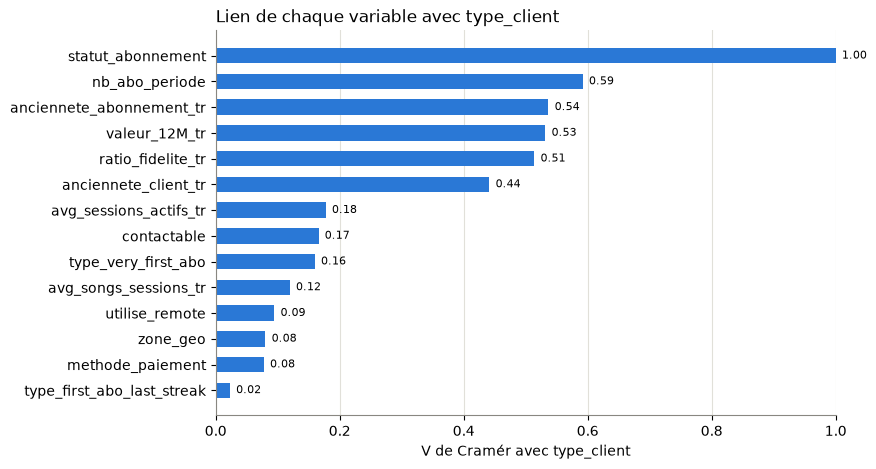

In [24]:
# La colonne "type_client" de la matrice, sans type_client elle-même, triée
lien_type_client = matrice_v["type_client"].drop("type_client").sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(lien_type_client.index, lien_type_client.values, color=BLEU, height=0.6)
ax.grid(axis="x")
ax.grid(axis="y", visible=False)
ax.set_xlabel("V de Cramér avec type_client")
ax.set_xlim(0, 1)
for position, valeur in enumerate(lien_type_client.values):   # valeur écrite au bout de la barre
    ax.text(valeur + 0.01, position, f"{valeur:.2f}", va="center", fontsize=8)
ax.set_title("Lien de chaque variable avec type_client", loc="left")
plt.show()

## 8. Conclusions : les décisions à prendre avant l'ACM

*(Cette partie résume les résultats obtenus ci-dessus.)*

### Variables à retirer ou à mettre en illustratives
| Variable | Décision | Raison |
|---|---|---|
| `id_anonyme` | retirer | identifiant |
| `statut_abonnement` | retirer | doublon parfait de `type_client` (V = 1) |
| `type_first_abo_last_streak` | retirer ou illustrative | 99,1 % « payant », quasi constante |
| `type_client` | illustrative (conseillé) | c'est ce qu'on veut expliquer ensuite ; en active, elle orienterait les axes |
| `contactable` | illustrative | information marketing, pas un comportement d'usage |

### Modalités à regrouper
- **`nb_abo_periode`** : découper en classes (forme en U → garder 1 et 12 seuls, regrouper le milieu).
- **`methode_paiement`** : réunir `Others`, `Credit`, `Amazon` (le lien fort avec `type_first_abo_last_streak` vient de `Credit`).
- **`zone_geo`** : réunir les petites zones (`Autre/Inconnu`, `Afrique`, `Asie`, `Amerique_Sud`, `Amerique_Nord_Autre`, `Oceanie`).
- **`type_very_first_abo`** : réunir `offert` et `reduc`.
- **Anciennetés, sessions, chansons, valeur** : réduire à environ 4 à 6 classes pour qu'elles ne pèsent pas plus que les autres variables.

### Points à garder en tête pour interpréter l'ACM
- Les modalités « vient de s'abonner » / « moins d'1 mois » et « pas de session » (dans deux variables)
  concernent **exactement les mêmes clients** : elles formeront probablement chacune un axe « évident ».
- `contactable` est assez liée à l'ancienneté client (V = 0,35) : c'est un argument de plus pour la
  garder en illustrative, sinon elle renforcerait l'axe « ancienneté ».
- Les liens forts `nb_abo_periode` ↔ `valeur_12M_tr` et ancienneté client ↔ abonnement sont
  logiques et pas totaux : on garde les deux variables de chaque couple.

**Étape suivante :** appliquer ces regroupements (script `regroupements.py`), puis recalculer
le V de Cramér sur le fichier regroupé pour vérifier que les liens tiennent toujours.